In [1]:
import cupy as np
import cupy.fft as fft
from time import time
# import h5py
import pathlib,json
import matplotlib.pyplot as plt


In [23]:
data = np.loadtxt('harshit_2.txt').T
data.shape
# data = np.load(f"/home/rajarshi.chattopadhyay/fluid/2DV_and_particles/data_bspline/Re_125000.0,dt_0.005,N_1024/time_662.80/w.npz")['vorticity']
# data.shape

(1024, 1024)

In [24]:
## Forming the 2D grid (position space)
N = data.shape[0]
Nx, Ny = N,N
ifft2 = lambda x: fft.irfft2(x,(Nx,Ny))
N = Nx
d = 2
TWO_PI = 2* np.pi
Lx, Ly = (2*np.pi),(2*np.pi) #Length of the grid
X,Y = np.linspace(0,Lx,Nx,endpoint= False), np.linspace(0,Ly,Ny,endpoint= False)
dx = X[1] - X[0]
dy = Y[1] - Y[0]
x,y = np.meshgrid(X,Y,indexing="ij")

## It is best to define the function which returns the real part of the iifted function as ifft. 

## Forming the 2D grid (k space)
Kx = 2*np.pi*np.linspace(-(Nx//2) , Nx//2 - 0.5*(1+ (-1)**(Nx%2)),Nx)/Lx
Ky = 2*np.pi*np.linspace(-(Ny//2) , Ny//2 - 0.5*(1+ (-1)**(Ny%2)),Ny)/Ly
Kx = np.append(Kx[Kx>=0], Kx[Kx<0])
Ky = np.append(Ky[Ky>=0], -Ky[0])
kx,ky = np.meshgrid(Kx,Ky,indexing="ij")
kxint = np.round(ky).astype(int)
kyint = np.round(ky).astype(int)
k = (kx**2 + ky**2)**0.5
## Defining the inverese laplacian.
lap = -(kx**2 + ky**2)
lapinv = 1.0/np.where(lap == 0., np.inf, lap)
Nf = Nx//2 + 1
shells = np.arange(-0.5, round(Nf*d**0.5) + 0.5)
shells[0] = 0. 
normalize = np.where((ky== 0) + (ky == Ny//2) , 1/(Nx**4),2/(Nx**4))
dalcutoff = ((2*np.pi*Nx)/Lx)//3,((2*np.pi*Ny)/Ly)//3
# dealias = (abs(kx)<dalcutoff[0])*(abs(ky)<dalcutoff[1])  
dealias = 1.0 

In [25]:
def e2d_to_1d(x):
    return (np.histogram(k.ravel(),bins = shells,weights=x.ravel() )[0]).real

In [30]:
xi_r = data
xi = fft.rfft2(xi_r)
# xi = data
psi = -lapinv*xi*dealias
ur = ifft2(1j * ky*psi)
vr = ifft2(-1j * kx*psi) 
xi_xr = ifft2(1j * kx*xi)
xi_yr = ifft2(1j * ky*xi)
advterm_xi= -1.0*fft.rfft2(ur*xi_xr + vr*xi_yr)*dealias
advterm_psi = -lapinv*advterm_xi
advterm_u = 1j * ky*advterm_psi
advterm_v = -1j * kx*advterm_psi

In [31]:
Tk = np.real(np.conjugate(fft.rfft2(ur))*advterm_u + np.conjugate(fft.rfft2(vr))*advterm_v)*dealias*normalize
Tomgk = np.real(np.conjugate(xi)*advterm_xi)*dealias*normalize
ek = 0.5*(np.abs(fft.rfft2(ur))**2 + np.abs(fft.rfft2(vr))**2)*normalize*dealias
ek1d = e2d_to_1d(ek)
Tk1d = e2d_to_1d(Tk)
Tomgk1d = e2d_to_1d(Tomgk)

In [32]:
Pk1d = np.cumsum(Tk1d[::-1])[::-1]
Pomgk1d = np.cumsum(Tomgk1d[::-1])[::-1]
Pk1d[0],Pk1d[-1],Pomgk1d[0],Pomgk1d[-1]

(array(2.60911559e-17),
 array(0.),
 array(-1.03930914e-11),
 array(3.01905234e-14))

In [33]:
ur.std()

array(0.07700786)

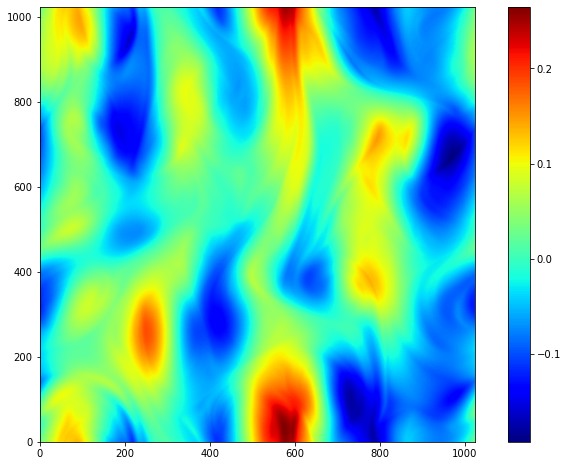

In [34]:
fig,ax = plt.subplots(1,1,figsize = (12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
p1 = plt.imshow(ur.get(),origin = 'lower',cmap = 'jet')
plt.colorbar(p1)

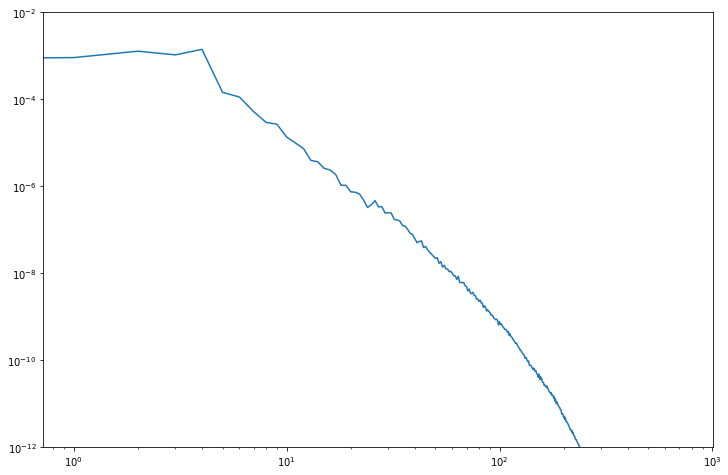

In [35]:
fig,ax = plt.subplots(1,1,figsize = (12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
plt.plot(np.arange(len(Pk1d)).get(),ek1d.get())
plt.ylim(1e-12,1e-2)
plt.xscale('log')
plt.yscale('log')

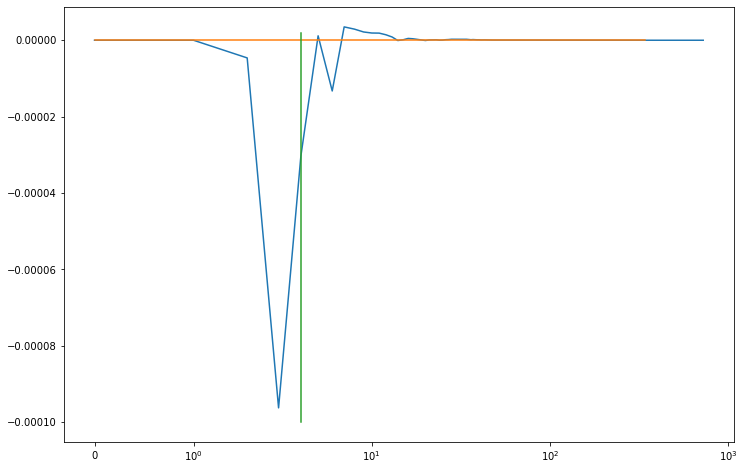

In [36]:
fig,ax = plt.subplots(1,1,figsize = (12,8))
fig.patch.set_facecolor('white')
fig.patch.set_alpha(1.0)
plt.plot(np.arange(len(Tk1d)).get(),Pk1d.get())
plt.plot([0,1024//3],[0,0])
plt.plot([4,4],[-1e-4,2e-6])
# plt.xlim(0,20)
plt.xscale('symlog',linthresh=1,linscale = 0.5)